# Member 5 - Random Forest Regressor
## Medical Insurance Charges Prediction

### Objective
The objective of this model is to predict medical insurance charges using a Random Forest Regressor and identify a suitable model configuration through hyperparameter tuning.

### Model Suitability
Random Forest Regression is suitable for predicting the continuous target variable `charges`. It combines predictions from multiple decision trees and can capture complex nonlinear relationships and interactions between features.

Compared with a single Decision Tree, Random Forest can provide more stable predictions and reduce overfitting by combining multiple trees. It can also provide feature importance values that help identify influential input features.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import (
    GridSearchCV,
    cross_val_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
candidate_roots = [
    Path("."),
    Path("..")
]

project_root = None

for root in candidate_roots:

    train_file = (
        root
        / "data"
        / "processed"
        / "insurance_train_processed.csv"
    )

    test_file = (
        root
        / "data"
        / "processed"
        / "insurance_test_processed.csv"
    )

    if train_file.exists() and test_file.exists():
        project_root = root
        break


if project_root is None:
    raise FileNotFoundError(
        "Processed train/test CSV files were not found. "
        "Check the data/processed folder."
    )


TRAIN_PATH = (
    project_root
    / "data"
    / "processed"
    / "insurance_train_processed.csv"
)

TEST_PATH = (
    project_root
    / "data"
    / "processed"
    / "insurance_test_processed.csv"
)

RESULT_PATH = (
    project_root
    / "results"
    / "model_results"
)

FIGURE_PATH = (
    project_root
    / "results"
    / "model_visualizations"
)


RESULT_PATH.mkdir(
    parents=True,
    exist_ok=True
)

FIGURE_PATH.mkdir(
    parents=True,
    exist_ok=True
)


print("Project root :", project_root)
print("Train file   :", TRAIN_PATH)
print("Test file    :", TEST_PATH)

Project root : ..
Train file   : ..\data\processed\insurance_train_processed.csv
Test file    : ..\data\processed\insurance_test_processed.csv


In [3]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)


print("Training Dataset Shape:", train_df.shape)
print("Testing Dataset Shape :", test_df.shape)


print("\nTraining Data:")
display(train_df.head())


print("\nTesting Data:")
display(test_df.head())


print(
    "\nTraining Missing Values:",
    train_df.isnull().sum().sum()
)

print(
    "Testing Missing Values:",
    test_df.isnull().sum().sum()
)


if "charges" not in train_df.columns:
    raise ValueError(
        "'charges' target column is missing from training data."
    )

if "charges" not in test_df.columns:
    raise ValueError(
        "'charges' target column is missing from testing data."
    )

Training Dataset Shape: (1069, 8)
Testing Dataset Shape : (268, 8)

Training Data:


,smoker_yes,age_bmi_interaction,age,bmi,region_southeast,children,sex_male,charges
0,0,-1.238193,-1.157680,-1.002462,0,-0.907908,1,2396.09590
1,0,-1.282622,-1.300619,-0.796635,0,0.766904,1,3279.86855
2,0,1.432285,0.914926,1.166632,0,0.766904,0,33471.97189
3,0,2.705024,1.701087,1.824110,1,-0.907908,1,13405.39030
4,0,0.082968,0.557580,-0.654140,0,0.766904,0,9715.84100



Testing Data:


,smoker_yes,age_bmi_interaction,age,bmi,region_southeast,children,sex_male,charges
0,0,-0.199877,0.700518,-1.334950,0,-0.907908,1,8688.85885
1,0,-0.894330,-0.728865,-0.820801,0,2.441716,0,5708.86700
2,0,1.248171,0.843457,0.976639,0,1.604310,0,11436.73815
3,1,-0.271365,-0.585927,0.644150,0,1.604310,1,38746.35510
4,0,-0.032718,-0.585927,1.310794,1,0.766904,1,4463.20510



Training Missing Values: 0
Testing Missing Values: 0


In [4]:
X_train = train_df.drop(
    columns=["charges"]
)

y_train = train_df["charges"]


X_test = test_df.drop(
    columns=["charges"]
)

y_test = test_df["charges"]


if list(X_train.columns) != list(X_test.columns):
    raise ValueError(
        "Training and testing feature columns do not match."
    )


print("X_train Shape:", X_train.shape)
print("y_train Shape:", y_train.shape)

print("X_test Shape :", X_test.shape)
print("y_test Shape :", y_test.shape)


print("\nFeatures Used:")

for feature in X_train.columns:
    print("-", feature)


print("\nTarget Statistics:")
display(y_train.describe())

X_train Shape: (1069, 7)
y_train Shape: (1069,)
X_test Shape : (268, 7)
y_test Shape : (268,)

Features Used:
- smoker_yes
- age_bmi_interaction
- age
- bmi
- region_southeast
- children
- sex_male

Target Statistics:


count     1069.000000
mean     13030.203369
std      11706.530971
min       1121.873900
25%       4747.052900
50%       9290.139500
75%      16450.894700
max      62592.873090
Name: charges, dtype: float64

In [5]:
def evaluate_model(
    model_name,
    y_true,
    y_pred
):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )


    print(f"\n{model_name}")
    print("-" * 50)

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")


    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

## Evaluation, Validation and Implementation

### Evaluation Metrics
The model is evaluated using:

- **MAE:** Measures the average absolute prediction error. Lower values indicate better performance.
- **RMSE:** Gives a larger penalty to large prediction errors. Lower values indicate better performance.
- **R²:** Measures how much variation in insurance charges is explained by the model. Higher values generally indicate better performance.

### Validation and Hyperparameter Tuning
Five-fold cross-validation is used during GridSearchCV to evaluate different Random Forest configurations.

The following hyperparameters are tuned:

- **n_estimators:** Number of decision trees in the forest.
- **max_depth:** Maximum depth allowed for each tree.
- **min_samples_split:** Minimum number of samples required to split a node.
- **min_samples_leaf:** Minimum number of samples required at a leaf node.

### Implementation
Scikit-learn `RandomForestRegressor` is used to build the model and `GridSearchCV` is used for hyperparameter tuning. A baseline Random Forest is first evaluated and then compared with the tuned model. Feature importance is also examined to understand the contribution of the input features.

In [6]:
rf_baseline = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)


rf_baseline.fit(
    X_train,
    y_train
)


baseline_predictions = (
    rf_baseline.predict(
        X_test
    )
)


baseline_result = evaluate_model(
    "Random Forest - Baseline",
    y_test,
    baseline_predictions
)


Random Forest - Baseline
--------------------------------------------------
MAE  : 2685.3543
RMSE : 4763.5546
R²   : 0.8765


In [7]:
param_grid = {
    "n_estimators": [
        100,
        200,
        300
    ],

    "max_depth": [
        None,
        5,
        10,
        20
    ],

    "min_samples_split": [
        2,
        5,
        10
    ],

    "min_samples_leaf": [
        1,
        2,
        4
    ]
}


rf_model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)


grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    return_train_score=True
)


grid_search.fit(
    X_train,
    y_train
)


print(
    "Best Parameters:",
    grid_search.best_params_
)

print(
    "Best Cross-Validation RMSE:",
    -grid_search.best_score_
)

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Best Cross-Validation RMSE: 4619.76195906487


In [8]:
cv_results = pd.DataFrame(
    grid_search.cv_results_
)


tuning_results = pd.DataFrame({
    "N_Estimators":
        cv_results[
            "param_n_estimators"
        ].astype(int),

    "Max_Depth":
        cv_results[
            "param_max_depth"
        ],

    "Min_Samples_Split":
        cv_results[
            "param_min_samples_split"
        ].astype(int),

    "Min_Samples_Leaf":
        cv_results[
            "param_min_samples_leaf"
        ].astype(int),

    "Mean_Train_RMSE":
        -cv_results[
            "mean_train_score"
        ],

    "Mean_CV_RMSE":
        -cv_results[
            "mean_test_score"
        ],

    "CV_RMSE_STD":
        cv_results[
            "std_test_score"
        ]
})


tuning_results = (
    tuning_results
    .sort_values(
        "Mean_CV_RMSE"
    )
    .reset_index(
        drop=True
    )
)


print(
    "Top 10 Random Forest Configurations:"
)

display(
    tuning_results.head(10)
)

Top 10 Random Forest Configurations:


,N_Estimators,Max_Depth,Min_Samples_Split,Min_Samples_Leaf,Mean_Train_RMSE,Mean_CV_RMSE,CV_RMSE_STD
0,200,5,10,4,4073.224684,4619.761959,430.813195
1,200,5,2,4,4062.054372,4621.118985,430.776484
2,200,5,5,4,4062.054372,4621.118985,430.776484
3,100,5,10,4,4075.675177,4623.774809,431.209729
4,300,5,10,4,4072.895485,4623.795199,435.399441
5,300,5,2,4,4061.564759,4625.114782,435.240997
6,300,5,5,4,4061.564759,4625.114782,435.240997
7,100,5,2,4,4063.854933,4626.233839,429.970130
8,100,5,5,4,4063.854933,4626.233839,429.970130
9,200,5,10,2,4033.283671,4630.610634,431.494491


In [9]:
best_rf_model = (
    grid_search.best_estimator_
)


best_params = (
    grid_search.best_params_
)


tuned_predictions = (
    best_rf_model.predict(
        X_test
    )
)


tuned_result = evaluate_model(
    "Random Forest - Tuned",
    y_test,
    tuned_predictions
)


print("\nBest Parameters:")

for parameter, value in best_params.items():
    print(
        f"{parameter}: {value}"
    )


Random Forest - Tuned
--------------------------------------------------
MAE  : 2415.0114
RMSE : 4254.5807
R²   : 0.9015

Best Parameters:
max_depth: 5
min_samples_leaf: 4
min_samples_split: 10
n_estimators: 200


In [10]:
rf_results = pd.DataFrame([
    baseline_result,
    tuned_result
])


rf_results = (
    rf_results
    .sort_values(
        by="RMSE"
    )
    .reset_index(
        drop=True
    )
)


print(
    "Baseline vs Tuned Random Forest:"
)

display(
    rf_results
)

Baseline vs Tuned Random Forest:


,Model,MAE,RMSE,R2
0,Random Forest - Tuned,2415.011356,4254.580654,0.901492
1,Random Forest - Baseline,2685.354314,4763.554584,0.876513


In [11]:
cv_scores = cross_val_score(

    best_rf_model,

    X_train,

    y_train,

    cv=5,

    scoring="neg_root_mean_squared_error",

    n_jobs=-1
)


cv_rmse_scores = -cv_scores


print(
    "Final Random Forest - 5-Fold CV RMSE Scores:"
)


for fold, score in enumerate(
    cv_rmse_scores,
    start=1
):

    print(
        f"Fold {fold}: {score:.4f}"
    )


print(
    f"\nMean CV RMSE: "
    f"{cv_rmse_scores.mean():.4f}"
)

print(
    f"CV RMSE Standard Deviation: "
    f"{cv_rmse_scores.std():.4f}"
)

Final Random Forest - 5-Fold CV RMSE Scores:
Fold 1: 5466.7029
Fold 2: 4438.1331
Fold 3: 4384.4604
Fold 4: 4282.5260
Fold 5: 4526.9874

Mean CV RMSE: 4619.7620
CV RMSE Standard Deviation: 430.8132


In [12]:
final_rf_result = evaluate_model(
    "Random Forest - Final Tuned Model",
    y_test,
    tuned_predictions
)


feature_importance = pd.DataFrame({
    "Feature":
        X_train.columns,

    "Importance":
        best_rf_model.feature_importances_
})


feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print("\nFeature Importance:")

display(
    feature_importance
)


print(
    "\nMean 5-Fold CV RMSE:",
    round(
        cv_rmse_scores.mean(),
        4
    )
)


Random Forest - Final Tuned Model
--------------------------------------------------
MAE  : 2415.0114
RMSE : 4254.5807
R²   : 0.9015

Feature Importance:


,Feature,Importance
0,smoker_yes,0.681396
1,bmi,0.172460
2,age,0.100560
3,age_bmi_interaction,0.032654
4,children,0.011349
5,region_southeast,0.001016
6,sex_male,0.000566



Mean 5-Fold CV RMSE: 4619.762


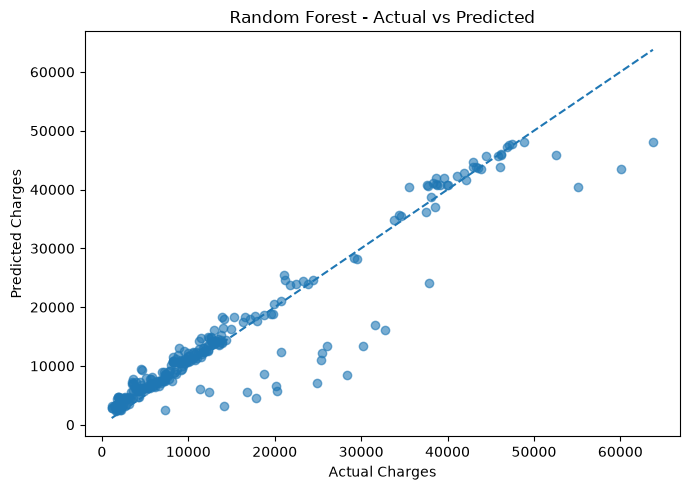

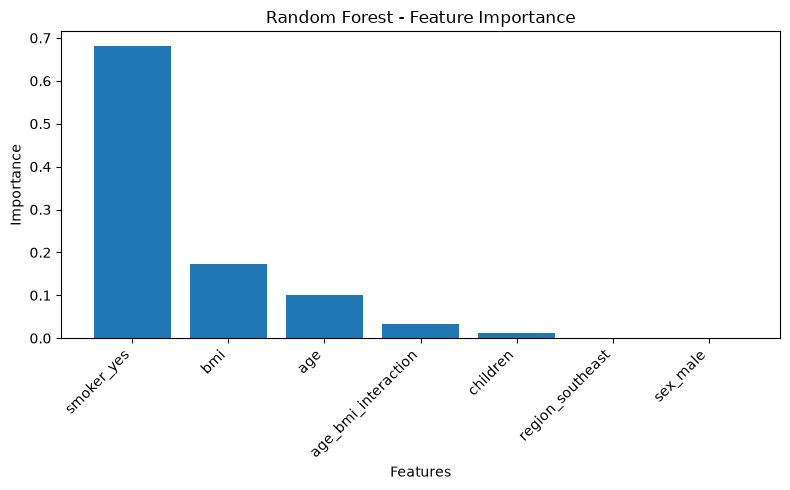

In [13]:
# Actual vs Predicted
plt.figure(
    figsize=(7, 5)
)


plt.scatter(
    y_test,
    tuned_predictions,
    alpha=0.6
)


minimum_value = min(
    y_test.min(),
    tuned_predictions.min()
)

maximum_value = max(
    y_test.max(),
    tuned_predictions.max()
)


plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    "--"
)


plt.xlabel(
    "Actual Charges"
)

plt.ylabel(
    "Predicted Charges"
)

plt.title(
    "Random Forest - Actual vs Predicted"
)


plt.tight_layout()


plt.savefig(
    FIGURE_PATH
    / "random_forest_actual_vs_predicted.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# Feature Importance
plt.figure(
    figsize=(8, 5)
)


plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)


plt.xlabel(
    "Features"
)

plt.ylabel(
    "Importance"
)

plt.title(
    "Random Forest - Feature Importance"
)


plt.xticks(
    rotation=45,
    ha="right"
)


plt.tight_layout()


plt.savefig(
    FIGURE_PATH
    / "random_forest_feature_importance.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()

In [14]:
# Baseline vs tuned
rf_results.to_csv(
    RESULT_PATH
    / "random_forest_results.csv",
    index=False
)


# All tuning configurations
tuning_results.to_csv(
    RESULT_PATH
    / "random_forest_tuning_results.csv",
    index=False
)


# Feature importance
feature_importance.to_csv(
    RESULT_PATH
    / "random_forest_feature_importance.csv",
    index=False
)


# Final result for group comparison
best_rf_result = pd.DataFrame([
    {
        "Model":
            "Random Forest Regressor",

        "Best_Configuration":
            str(best_params),

        "MAE":
            final_rf_result["MAE"],

        "RMSE":
            final_rf_result["RMSE"],

        "R2":
            final_rf_result["R2"],

        "CV_RMSE":
            cv_rmse_scores.mean()
    }
])


best_rf_result.to_csv(
    RESULT_PATH
    / "random_forest_best.csv",
    index=False
)


print("Random Forest Results:")
display(rf_results)


print("\nTop 10 Tuning Results:")
display(
    tuning_results.head(10)
)


print("\nFeature Importance:")
display(
    feature_importance
)


print("\nBest Random Forest Result:")
display(
    best_rf_result
)


print("\nResults saved successfully.")

Random Forest Results:


,Model,MAE,RMSE,R2
0,Random Forest - Tuned,2415.011356,4254.580654,0.901492
1,Random Forest - Baseline,2685.354314,4763.554584,0.876513



Top 10 Tuning Results:


,N_Estimators,Max_Depth,Min_Samples_Split,Min_Samples_Leaf,Mean_Train_RMSE,Mean_CV_RMSE,CV_RMSE_STD
0,200,5,10,4,4073.224684,4619.761959,430.813195
1,200,5,2,4,4062.054372,4621.118985,430.776484
2,200,5,5,4,4062.054372,4621.118985,430.776484
3,100,5,10,4,4075.675177,4623.774809,431.209729
4,300,5,10,4,4072.895485,4623.795199,435.399441
5,300,5,2,4,4061.564759,4625.114782,435.240997
6,300,5,5,4,4061.564759,4625.114782,435.240997
7,100,5,2,4,4063.854933,4626.233839,429.970130
8,100,5,5,4,4063.854933,4626.233839,429.970130
9,200,5,10,2,4033.283671,4630.610634,431.494491



Feature Importance:


,Feature,Importance
0,smoker_yes,0.681396
1,bmi,0.172460
2,age,0.100560
3,age_bmi_interaction,0.032654
4,children,0.011349
5,region_southeast,0.001016
6,sex_male,0.000566



Best Random Forest Result:


,Model,Best_Configuration,MAE,RMSE,R2,CV_RMSE
0,Random Forest Regressor,"{'max_depth': 5, 'min_samples_leaf': 4, 'min_s...",2415.011356,4254.580654,0.901492,4619.761959



Results saved successfully.


## Conclusion, Limitations and Improvements

### Conclusion
A baseline Random Forest model and multiple tuned Random Forest configurations were evaluated. GridSearchCV with five-fold cross-validation was used to test different combinations of `n_estimators`, `max_depth`, `min_samples_split`, and `min_samples_leaf`.

The baseline and tuned models were compared using MAE, RMSE, and R². Feature importance was also examined to understand which input features contributed most to the model's predictions. The tuned Random Forest result is saved for the final group-level model comparison.

### Limitations
- Random Forest is less interpretable than a single Decision Tree or Linear Regression.
- Training and hyperparameter tuning can be computationally expensive because many trees and parameter combinations are evaluated.
- A complex forest can require more memory and prediction time.
- Feature importance shows how useful features were to the fitted model but should not be interpreted as a causal relationship.

### Possible Improvements
- Further refine the hyperparameter search around the best configuration.
- Investigate additional parameters such as `max_features`.
- Apply additional feature engineering where appropriate.
- Compare Random Forest performance with the other regression models using the same evaluation metrics and test data.